In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


In [2]:
calls = pd.read_csv('megaline_calls.csv')
internet = pd.read_csv('megaline_internet.csv')
messages = pd.read_csv('megaline_messages.csv')
plans = pd.read_csv('megaline_plans.csv')
users = pd.read_csv('megaline_users.csv')

In [3]:

calls.head()

,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


In [4]:
internet.head()


,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


In [5]:
messages.head()

,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


In [6]:
plans.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


In [7]:
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN


In [8]:
#convertir fechas
calls['call_date'] = pd.to_datetime(calls['call_date'])
messages['message_date'] = pd.to_datetime(messages['message_date'])
internet['session_date'] = pd.to_datetime(internet['session_date'])
users['reg_date'] = pd.to_datetime(users['reg_date'])
calls.info()
messages.info()
internet.info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 4.2+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.7+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (to

In [9]:
#crear columna por mes para analizar
calls['month'] = calls['call_date'].dt.month
messages['month'] = messages['message_date'].dt.month
internet['month'] = internet['session_date'].dt.month

calls[['call_date', 'month']].head()


,call_date,month
0,2018-12-27,12
1,2018-12-27,12
2,2018-12-27,12
3,2018-12-28,12
4,2018-12-30,12


In [10]:
#redondear llamadas
calls['duration'] = np.ceil(calls['duration'])
calls['duration'].head(10)

0     9.0
1    14.0
2    15.0
3     6.0
4     5.0
5     3.0
6     6.0
7    15.0
8     6.0
9     5.0
Name: duration, dtype: float64

In [11]:
#Agrupar datos -calls
calls_grouped = calls.groupby(['user_id', 'month']).agg({
    'duration': 'sum',
    'id': 'count'
}).reset_index()

calls_grouped.columns = ['user_id', 'month', 'minutes', 'calls']
calls_grouped.head()

,user_id,month,minutes,calls
0,1000,12,124.0,16
1,1001,8,182.0,27
2,1001,9,315.0,49
3,1001,10,393.0,65
4,1001,11,426.0,64


In [12]:
#agrupar datos -messages
messages_grouped = messages.groupby(['user_id', 'month']).agg({
    'id': 'count'
}).reset_index()

messages_grouped.columns = ['user_id', 'month', 'messages']
messages_grouped.head()

,user_id,month,messages
0,1000,12,11
1,1001,8,30
2,1001,9,44
3,1001,10,53
4,1001,11,36


In [13]:
#agrupar datos -internet convertir a GB
internet_grouped = internet.groupby(['user_id', 'month']).agg({
    'mb_used': 'sum'
}).reset_index()

internet_grouped['gb_used'] = np.ceil(internet_grouped['mb_used'] / 1024)
internet_grouped.head()

,user_id,month,mb_used,gb_used
0,1000,12,1901.47,2.0
1,1001,8,6919.15,7.0
2,1001,9,13314.82,14.0
3,1001,10,22330.49,22.0
4,1001,11,18504.30,19.0


In [14]:
#unir todo
data = calls_grouped.merge(messages_grouped, on=['user_id', 'month'], how='outer')
data = data.merge(internet_grouped, on=['user_id', 'month'], how='outer')
data = data.merge(users, on='user_id', how='left')
data = data.merge(plans, left_on='plan', right_on='plan_name', how='left')

data.fillna(0, inplace=True)
data.head()

,user_id,month,minutes,calls,messages,mb_used,gb_used,first_name,last_name,age,...,plan,churn_date,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,1000,12,124.0,16.0,11.0,1901.47,2.0,Anamaria,Bauer,45,...,ultimate,0,1000,30720,3000,70,7,0.01,0.01,ultimate
1,1001,8,182.0,27.0,30.0,6919.15,7.0,Mickey,Wilkerson,28,...,surf,0,50,15360,500,20,10,0.03,0.03,surf
2,1001,9,315.0,49.0,44.0,13314.82,14.0,Mickey,Wilkerson,28,...,surf,0,50,15360,500,20,10,0.03,0.03,surf
3,1001,10,393.0,65.0,53.0,22330.49,22.0,Mickey,Wilkerson,28,...,surf,0,50,15360,500,20,10,0.03,0.03,surf
4,1001,11,426.0,64.0,36.0,18504.30,19.0,Mickey,Wilkerson,28,...,surf,0,50,15360,500,20,10,0.03,0.03,surf


In [19]:
#Calcular ingresos
def calculate_revenue(row):
    minutes_extra = max(0, row['minutes'] - row['minutes_included'])
    messages_extra = max(0, row['messages'] - row['messages_included'])
    gb_extra = max(0, row['gb_used'] - (row['mb_per_month_included'] / 1024))

    revenue = (
        row['usd_monthly_pay'] +
        minutes_extra * row['usd_per_minute'] +
        messages_extra * row['usd_per_message'] +
        gb_extra * row['usd_per_gb']
    )
    
    return revenue

In [20]:

data[['user_id', 'plan', 'minutes', 'messages', 'gb_used']].head()


,user_id,plan,minutes,messages,gb_used
0,1000,ultimate,124.0,11.0,2.0
1,1001,surf,182.0,30.0,7.0
2,1001,surf,315.0,44.0,14.0
3,1001,surf,393.0,53.0,22.0
4,1001,surf,426.0,36.0,19.0


In [21]:
data.columns

Index(['user_id', 'month', 'minutes', 'calls', 'messages', 'mb_used',
       'gb_used', 'first_name', 'last_name', 'age', 'city', 'reg_date', 'plan',
       'churn_date', 'messages_included', 'mb_per_month_included',
       'minutes_included', 'usd_monthly_pay', 'usd_per_gb', 'usd_per_message',
       'usd_per_minute', 'plan_name'],
      dtype='object')

In [22]:
data['revenue'] = data.apply(calculate_revenue, axis=1)


In [23]:
data[['plan', 'revenue']].head()

,plan,revenue
0,ultimate,70.00
1,surf,20.00
2,surf,20.00
3,surf,90.09
4,surf,60.00


In [24]:
#ingreso promedio por plan
data.groupby('plan')['revenue'].mean()

plan
surf        60.706408
ultimate    72.313889
Name: revenue, dtype: float64

In [25]:
#estadisticas completas
data.groupby('plan')['revenue'].agg(['mean', 'var', 'std'])

,mean,var,std
plan,,,
surf,60.706408,3067.835152,55.388042
ultimate,72.313889,129.848486,11.395108


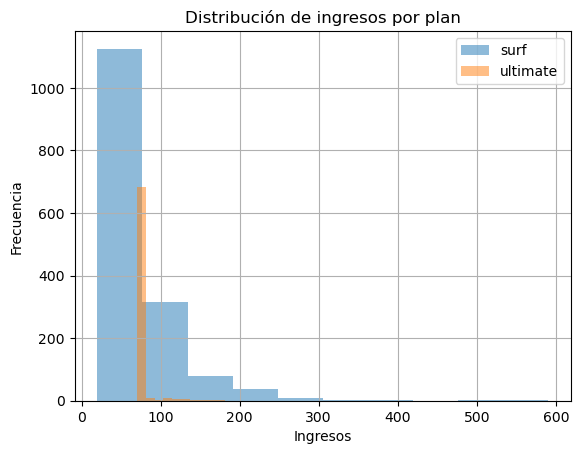

In [26]:
#histograma


for plan in ['surf', 'ultimate']:
    data[data['plan'] == plan]['revenue'].hist(alpha=0.5, label=plan)

plt.legend()
plt.title('Distribución de ingresos por plan')
plt.xlabel('Ingresos')
plt.ylabel('Frecuencia')
plt.show()

In [27]:
#hipotesis

surf = data[data['plan'] == 'surf']['revenue']
ultimate = data[data['plan'] == 'ultimate']['revenue']

alpha = 0.05

results = stats.ttest_ind(surf, ultimate)

print("p-value:", results.pvalue)

if results.pvalue < alpha:
    print("Rechazamos H0: los ingresos son diferentes")
else:
    print("No se puede rechazar H0")

p-value: 2.8626745106986436e-08
Rechazamos H0: los ingresos son diferentes


In [28]:
#hipotesis 2
data['ny_nj'] = data['city'].str.contains('NY|NJ', na=False)

ny = data[data['ny_nj']]['revenue']
other = data[~data['ny_nj']]['revenue']

results = stats.ttest_ind(ny, other)

print("p-value:", results.pvalue)

p-value: 0.11013307329186472


## Conclusión··

El análisis muestra que el plan [Surf/Ultimate] genera mayores ingresos promedio por usuario.

Las pruebas estadísticas indican que la diferencia entre los planes es [significativa / no significativa], lo que sugiere.

Por lo tanto, se recomienda enfocar la estrategia comercial en el plan más rentable.